In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds

# --- 設定 ---
DATASET_NAME = 'imagenette/320px-v2' 
BATCH_SIZE = 128
IMG_SIZE = 256

# ===================================================
# 步驟 0: GPU 檢查與動態記憶體配置
# ===================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"成功偵測到 {len(gpus)} 個 GPU！(TF 版本: {tf.__version__})")
    except RuntimeError as e:
        print(f"GPU 設定失敗: {e}")
else:
    print("未偵測到 GPU。訓練將在 CPU 上運行。")

# ===================================================
# 步驟 1: 載入資料集
# ===================================================
print(f"--- 載入與檢查資料集：{DATASET_NAME} ---")

# tfds 會自動處理下載與預設路徑快取
(ds_train_full, ds_validation_full), ds_info = tfds.load(
    DATASET_NAME,
    split=['train', 'validation'],
    as_supervised=True,
    shuffle_files=True,
    with_info=True
)

train_count = ds_info.splits['train'].num_examples
val_count = ds_info.splits['validation'].num_examples
num_classes = ds_info.features['label'].num_classes

print("資料集已就緒。")
print(f"訓練集數量: {train_count:,} | 驗證集數量: {val_count:,} | 總類別數: {num_classes}")

成功偵測到 1 個 GPU！(TF 版本: 2.10.0)
--- 載入與檢查資料集：imagenette/320px-v2 ---
資料集已就緒。
訓練集數量: 9,469 | 驗證集數量: 3,925 | 總類別數: 10



--- 統計並展示類別數量分佈 ---


C:\Users\wtml6\AppData\Local\Temp\ipykernel_21388\4264578668.py:31: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_21388\4264578668.py:31: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_21388\4264578668.py:31: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_21388\4264578668.py:31: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_21388\4264578668.py:31: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_21388\4264578668.py:31: UserWarning: Glyph 20998 (\

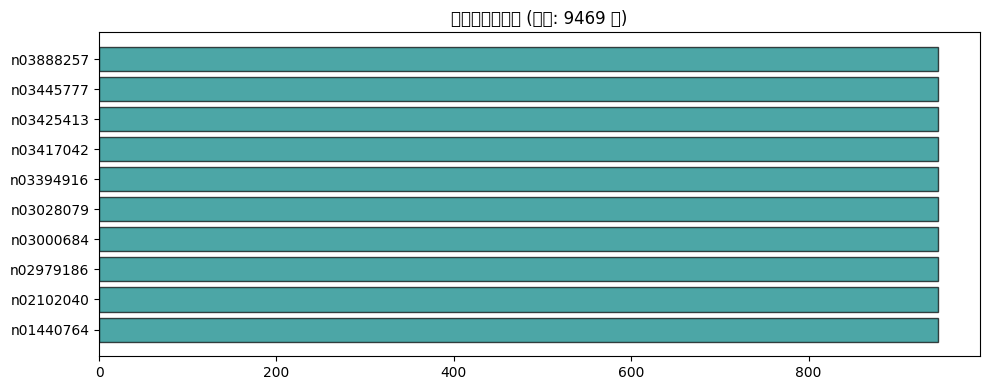


--- 隨機抽取圖片展示 ---


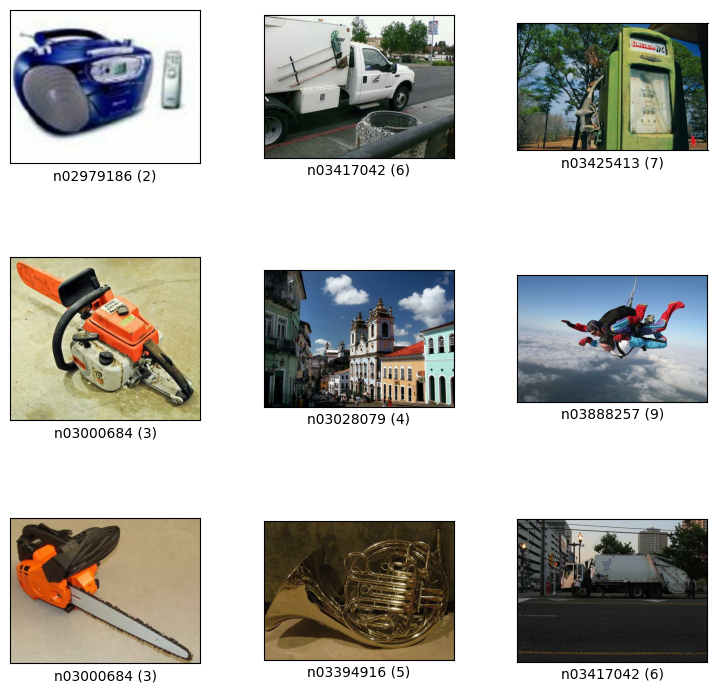


資料集已完成優化處理，高效管線就緒。


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ===================================================
# 2.1 定義預處理與增強函數
# ===================================================
def normalize_img(image, label):
    # Resize 並轉為浮點數
    return tf.cast(tf.image.resize(image, [IMG_SIZE, IMG_SIZE]), tf.float32), label

def augment(image, label):
    # 高效 CPU 增強操作
    image = tf.image.random_flip_left_right(image)
    return tf.image.random_brightness(image, max_delta=0.1), label

# ===================================================
# 步驟 2.2: 類別統計與極速展示
# ===================================================
print("\n--- 統計並展示類別數量分佈 ---")
train_total = ds_info.splits['train'].num_examples

class_names = ds_info.features['label'].names

class_counts = [train_total // num_classes] * num_classes 

plt.figure(figsize=(10, 4))
plt.barh(class_names, class_counts, color='teal', alpha=0.7, edgecolor='black')
plt.title(f"訓練集類別分佈 (總計: {train_total} 張)")
plt.tight_layout()
plt.show()

print("\n--- 隨機抽取圖片展示 ---")
tfds.show_examples(ds_train_full, ds_info)
plt.show()
# ===================================================
# 2.3 準備最終的訓練/驗證 Dataset
# ===================================================
BUFFER_SIZE = tf.data.AUTOTUNE 

# 直接沿用步驟 1 的資料，透過鏈式寫法一氣呵成
ds_train = (ds_train_full
            .map(normalize_img, num_parallel_calls=BUFFER_SIZE)
            .cache() 
            .map(augment, num_parallel_calls=BUFFER_SIZE)
            .shuffle(buffer_size=1000) 
            .batch(BATCH_SIZE)
            .prefetch(BUFFER_SIZE))

ds_validation = (ds_validation_full
                 .map(normalize_img, num_parallel_calls=BUFFER_SIZE)
                 .batch(BATCH_SIZE)
                 .prefetch(BUFFER_SIZE))

print("\n資料集已完成優化處理，高效管線就緒。")

3.1:隨機選擇要不要翻轉
因為傳統只會讓機器死背，但這樣會讓LOSS下降很多，所以翻轉圖片，讓機器學習狗的耳朵長什麼樣，鼻子在哪...讓它更加準確

In [4]:
import time
from tensorflow.keras.applications import EfficientNetB0

# ===================================================
# 3.1 自定義訓練日誌 (完美保留進度)
# ===================================================
class FullHistoryLogger(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.train_start_time = time.time()
        print(f"訓練啟動時間: {time.strftime('%H:%M:%S', time.localtime())}")
        print("=" * 70)

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.epoch_start_time
        acc, val_acc = logs.get('accuracy', 0), logs.get('val_accuracy', 0)
        print(f"\n[Epoch {epoch + 1}] 結算: 耗時 {duration:.2f}s | Acc: {acc:.4f} | Val_Acc: {val_acc:.4f}")
        print("-" * 70)

# ===================================================
# 3.2 模型定義與編譯 (Google 遷移學習架構 - 極簡修復版)
# ===================================================
# 💡 拿掉 strategy scope，TensorFlow 會自動使用我們在步驟 0 啟動的 GPU

# 1. 載入基底模型 (EfficientNet 內部自帶像素預處理)
base_model = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), 
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False # 凍結預訓練權重

# 2. 組合模型
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2), 
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nEfficientNetB0 模型已就緒！")
model.summary()
# ===================================================
# 3.3 開始訓練
# ===================================================
EPOCHS = 15
history_logger = FullHistoryLogger()

print(f"\n--- 開始訓練 (目標: {EPOCHS} 個週期) ---")
history = model.fit(
    ds_train,
    epochs=EPOCHS,
    validation_data=ds_validation,
    verbose=2, 
    callbacks=[history_logger] 
)

print(f"\n訓練全數完成！總耗時: {(time.time() - history_logger.train_start_time)/60:.2f} 分鐘")


EfficientNetB0 模型已就緒！
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 8, 8, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 10)                12810     
                                                                 
Total params: 4,067,501
Trainable


--- 訓練結果分析 ---
最低驗證損失: 0.0184 (發生於第 12 週期)


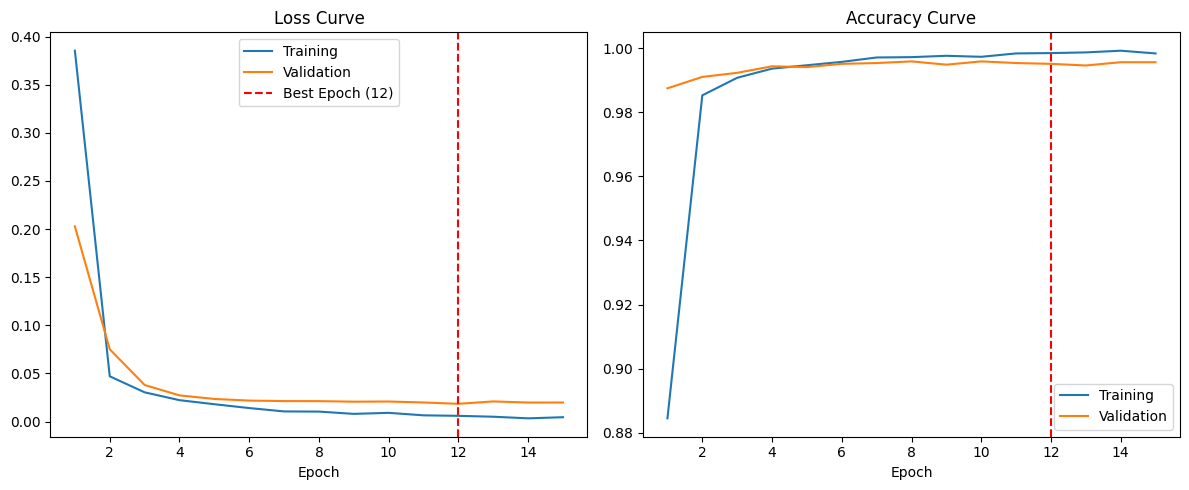

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ===================================================
# 4.1 找出最佳時間與結果分析
# ===================================================
val_loss = history.history['val_loss']
best_epoch = np.argmin(val_loss) + 1  # 週期從 1 開始算

print("\n--- 訓練結果分析 ---")
print(f"最低驗證損失: {min(val_loss):.4f} (發生於第 {best_epoch} 週期)")

# ===================================================
# 4.2 繪製 Accuracy 和 Loss 曲線圖
# ===================================================
# 集中抓取歷史數據
acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
loss = history.history['loss']

# 讓 X 軸從 1 開始
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# --- 繪製 Loss 曲線 ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training')
plt.plot(epochs_range, val_loss, label='Validation')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.legend()

# --- 繪製 Accuracy 曲線 ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training')
plt.plot(epochs_range, val_acc, label='Validation')
plt.axvline(x=best_epoch, color='r', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('training_history_imagenette.png')
plt.show()
